# Preprocessing

---

## Paso 1: Carga de Datos y Separación de Variables

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
X = pd.read_csv('train.csv', index_col='id')
X_test_full = pd.read_csv('test.csv', index_col='id')


# Remove rows with missing target, separate target from predictors
X.dropna(axis=0, subset=['Irrigation_Need'], inplace=True)
y = X['Irrigation_Need'].copy()              
X.drop(['Irrigation_Need'], axis=1, inplace=True)

# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                                random_state=0)

# Select categorical columns with relatively low cardinality (convenient but arbitrary)
low_cardinality_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and 
                        X_train_full[cname].dtype == "object"]
# Select numeric columns
numeric_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]


# Keep selected columns only
my_cols = low_cardinality_cols + numeric_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()



## Paso 2: Pipeline de Transformación

Desarrollamos la pipeline para transformar las variables, estándarizar los datos y entrenar un modelo.

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

scaler = MinMaxScaler()



categorical_transformer= Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
numerical_transformer = Pipeline(steps=[
    ('normalización', scaler)
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_cols),
        ('cat', categorical_transformer, low_cardinality_cols)])

## Paso 3: Definición del Modelo

Primero, partiré con un modelo simple para probar su desempeño, luego haré pruebas con más modelos de clasificación multiclase para ver si puedo mejorar el rendimiento.

In [3]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC, LinearSVC

model = OneVsRestClassifier(LinearSVC(random_state=0))

In [4]:
my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)
                             ])

## Paso 4: Entrenamiento y Evaluación

In [5]:
# Preprocessing of training data, fit model 
my_pipeline.fit(X_train, y_train)


# Preprocessing of validation data, get predictions
preds=my_pipeline.predict(X_valid)


# Evaluate the model
from sklearn.metrics import classification_report
print(classification_report(y_valid, preds))


              precision    recall  f1-score   support

        High       0.96      0.01      0.01      4183
         Low       0.90      0.92      0.91     73926
      Medium       0.80      0.84      0.82     47891

    accuracy                           0.86    126000
   macro avg       0.89      0.59      0.58    126000
weighted avg       0.86      0.86      0.84    126000



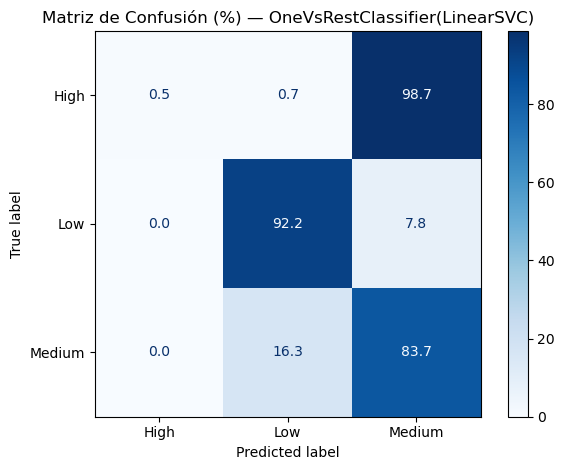

In [6]:
# Matriz de confusión en porcentaje
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, preds)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
labels = sorted(y_valid.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format='.1f')
plt.title("Matriz de Confusión (%) — OneVsRestClassifier(LinearSVC)")
plt.tight_layout()
plt.show()

# Modelado

---

## Paso 5: Comparación de Estrategias (OvR vs Softmax)

Comparamos **One-vs-Rest** (`LinearSVC`) contra **Softmax** (`LogisticRegression` con `multinomial`) para ver cuál generaliza mejor.

In [12]:
from sklearn.linear_model import LogisticRegression

models = {
    'OvR (LinearSVC)': OneVsRestClassifier(LinearSVC(random_state=0)),
    'Softmax (LogisticRegression)': LogisticRegression(
        solver='lbfgs', max_iter=1000, random_state=0
    ),
}

results = {}
for name, m in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', m)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_valid)
    report = classification_report(y_valid, preds, output_dict=True)
    results[name] = {
        'accuracy': report['accuracy'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_valid, preds))


  OvR (LinearSVC)
              precision    recall  f1-score   support

        High       0.96      0.01      0.01      4183
         Low       0.90      0.92      0.91     73926
      Medium       0.80      0.84      0.82     47891

    accuracy                           0.86    126000
   macro avg       0.89      0.59      0.58    126000
weighted avg       0.86      0.86      0.84    126000


  Softmax (LogisticRegression)
              precision    recall  f1-score   support

        High       0.79      0.58      0.67      4183
         Low       0.91      0.91      0.91     73926
      Medium       0.83      0.85      0.84     47891

    accuracy                           0.88    126000
   macro avg       0.84      0.78      0.81    126000
weighted avg       0.88      0.88      0.88    126000



In [7]:
pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)

,accuracy,macro_f1,weighted_f1
Softmax (LogisticRegression),0.875873,0.805560,0.875070
OvR (LinearSVC),0.859024,0.579618,0.844959


## Paso 6: Optimización de Hiperparámetros

Usamos `RandomizedSearchCV` para buscar los mejores hiperparámetros del modelo ganador. Es más eficiente que `GridSearchCV` cuando el espacio de búsqueda es grande.

*El mejor modelo fue LogisticRegression o Softmax.* Sin embargo, también probaremos con XGBClassifier para ver si mejora el rendimiento utilizando la GPU.

### Logistic Regresion (softmax)

In [15]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
import numpy as np
tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(solver='lbfgs', random_state=0))
])

# Espacio de búsqueda — los parámetros del modelo se acceden con "model__parametro"
param_distributions = {
    'model__C': np.logspace(-3, 3, 20),           # regularización
    'model__max_iter': [500, 1000, 2000],
}


#Usamos RandomizedSearchCV para buscar los mejores hiperparámetros del modelo ganador
search = GridSearchCV(
    tuning_pipeline,
    param_distributions,
    cv=5,
    scoring='balanced_accuracy', # Usamos balanced accuracy para evaluar el rendimiento en todas las clases,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'model__C': array([1.0000...00000000e+03]), 'model__max_iter': [500, 1000, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [14]:
from sklearn.linear_model import LogisticRegression

#Definimos el nuevo modelo y aplicamos la pipeline con los mejores hiperparámetros encontrados
model=LogisticRegression(solver='lbfgs', random_state=0,C=np.float64(233.57214690901213),max_iter=500)


#Entrenamos el modelo con la pipeline completa
my_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
#Revisamos las predicciones y el clasiffication report
preds_LR_best_params=my_pipeline.predict(X_valid)
print(classification_report(y_valid, preds_LR_best_params))

              precision    recall  f1-score   support

        High       0.79      0.58      0.67      4183
         Low       0.91      0.91      0.91     73926
      Medium       0.83      0.85      0.84     47891

    accuracy                           0.88    126000
   macro avg       0.84      0.78      0.81    126000
weighted avg       0.88      0.88      0.88    126000



La regresión lógistica no mostró ninguna mejora. Con los hiperparámetros optimizados. 

### XGBClassifier

In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
import numpy as np


# Codificar las etiquetas a valores numéricos (XGBoost lo requiere)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_valid_encoded = le.transform(y_valid)


tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
    device='cuda',
    n_estimators=300,
    random_state=0,
))
])

# Espacio de búsqueda — los parámetros del modelo se acceden con "model__parametro"
param_distributions = {
    'model__learning_rate': np.logspace(-3, 0, 20),           # tasa de aprendizaje
    'model__max_depth': [3, 5, 7, 9, 11],                     # profundidad máxima del árbol
    'model__n_estimators': [100, 200, 300, 400, 500],        # número de árboles
}


#Usamos RandomizedSearchCV para buscar los mejores hiperparámetros
search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions,
    n_iter=50,  # 50 combinaciones aleatorias (de 500 posibles)
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=1,  # n_jobs=1 para que XGBoost use la GPU correctamente
    verbose=1,
    random_state=0,
)

search.fit(X_train, y_train_encoded)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__learning_rate': array([0.001 ..., 1. ]), 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,n_iter,50
,scoring,'balanced_accuracy'
,n_jobs,1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,0
,error_score,nan


In [17]:
xgb_clasifier_predicts = le.inverse_transform(search.predict(X_valid))


  XGBClassifier
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4183
         Low       0.99      0.99      0.99     73926
      Medium       0.98      0.97      0.98     47891

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



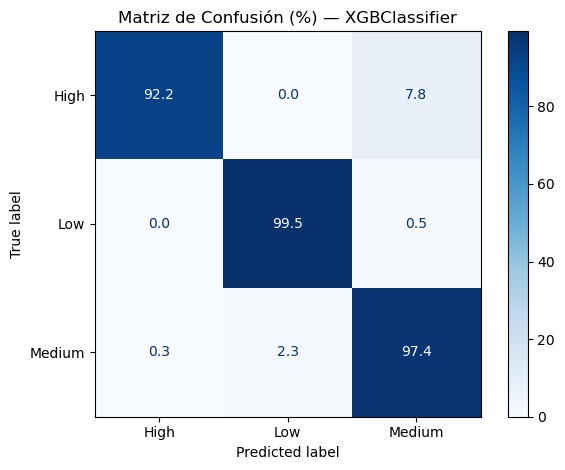

In [18]:
report = classification_report(y_valid, xgb_clasifier_predicts, output_dict=True)
resultados = {
        'accuracy': report['accuracy'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
print(f"\n{'='*50}")
print(f"  XGBClassifier")
print(f"{'='*50}")
print(classification_report(y_valid, xgb_clasifier_predicts))

# Matriz de confusión en porcentaje
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, xgb_clasifier_predicts)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
labels = sorted(y_valid.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format='.1f')
plt.title("Matriz de Confusión (%) — XGBClassifier")
plt.tight_layout()
plt.show()

## Paso 7: Exportar Predicciones

Generamos el archivo `submission.csv` con el formato requerido por la competencia para subirlo a Kaggle.

In [19]:
# Predecir sobre el set de test
test_preds = le.inverse_transform(search.predict(X_test))

# Crear DataFrame con el formato de submission
submission = pd.DataFrame({
    'id': X_test.index,
    'Irrigation_Need': test_preds
})

submission.to_csv('submission.csv', index=False)
print(f"Submission guardada: {submission.shape[0]} filas")
submission.head(10)

Submission guardada: 270000 filas


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low
